In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import os

sns.set_theme(style="whitegrid")
%matplotlib inline

# Load ablation results
data_path = "data/wfe_49_results.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Loaded: {data_path}")
    print(f"Number of items: {len(df)}")
else:
    raise FileNotFoundError(f"Results file not found: {data_path}")

Loaded: data/wfe_49_results.csv
Number of items: 1200


# Ablation Analysis: Unit 49 — Sequence Termination Control

This notebook analyzes the behavioral impact of ablating **unit 49** in the encoder hidden layer of a phoneme repetition model.

## Hypothesis

Unit 49 appears to function as a **sequence-maintenance mechanism**. When ablated, the model prematurely terminates sequences by generating `<EOS>` tokens too early.

## Key Findings (Preview)
- **~79%** of items show early termination after ablation
- On average, **~2 phonemes** are missing from truncated sequences
- The model still produces **correct prefixes** in ~80% of early-EOS cases

---

## 1. Setup and Data Loading

In [2]:
def parse_tokens(seq, keep_special=False):
    """Parse phoneme sequence from string, optionally keeping special tokens."""
    if pd.isna(seq):
        return []
    
    if isinstance(seq, str) and seq.startswith('['):
        try:
            tokens = ast.literal_eval(seq)
        except:
            tokens = seq.replace('[', '').replace(']', '').replace("'", "").split(', ')
    else:
        tokens = str(seq).split()
    
    if keep_special:
        return tokens
    return [t for t in tokens if t not in ['<PAD>', '<SOS>', '<EOS>']]

# Parse sequences
df['target_tokens'] = df['Phonemes'].apply(parse_tokens)
df['pred_tokens'] = df['Prediction'].apply(parse_tokens)

# Compute lengths
df['L_gold'] = df['target_tokens'].apply(len)
df['L_pred'] = df['pred_tokens'].apply(len)
df['len_diff'] = df['L_gold'] - df['L_pred']

print("Sample data:")
df[['Phonemes', 'Prediction', 'L_gold', 'L_pred']].head()

Sample data:


,Phonemes,Prediction,L_gold,L_pred
0,"['AH', 'T', 'EH', 'N', 'D', 'IH', 'NG']","['AH', 'T', 'EH', 'N', 'D', '<EOS>', '<PAD>']",7,5
1,"['K', 'AH', 'M', 'IH', 'SH', 'AH', 'N', 'ER']","['K', 'AH', 'M', 'IH', 'SH', '<EOS>', '<PAD>',...",8,5
2,"['AA', 'P', 'ER', 'EY', 'SH', 'AH', 'N']","['AA', 'P', 'ER', 'EY', '<EOS>', '<PAD>', '<PA...",7,4
3,"['HH', 'AA', 'S', 'P', 'IH', 'T', 'AH', 'L', 'Z']","['HH', 'AA', 'S', 'P', 'IH', 'L', '<EOS>', '<P...",9,6
4,"['AE', 'K', 'W', 'AH', 'Z', 'IH', 'SH', 'AH', ...","['AE', 'K', 'W', 'AH', '<EOS>', '<PAD>', '<PAD...",9,4


## 2. Preprocessing

Parse phoneme sequences from string representation and compute sequence lengths.

In [3]:
# Detect early termination
df['is_early_eos'] = df['L_pred'] < df['L_gold']

early_eos_rate = df['is_early_eos'].mean()
avg_missing = df[df['is_early_eos']]['len_diff'].mean()

print(f"Early-EOS (truncation) rate: {early_eos_rate:.2%}")
print(f"Mean missing phonemes: {avg_missing:.2f}")

# Check if truncated predictions are valid prefixes
def is_valid_prefix(row):
    lp = row['L_pred']
    if lp == 0:
        return False
    return row['target_tokens'][:lp] == row['pred_tokens'][:lp]

df['is_prefix'] = df.apply(is_valid_prefix, axis=1)
prefix_accuracy = df[df['is_early_eos']]['is_prefix'].mean()
print(f"Prefix accuracy (among truncations): {prefix_accuracy:.2%}")

Early-EOS (truncation) rate: 79.25%
Mean missing phonemes: 1.97
Prefix accuracy (among truncations): 80.13%


## 3. Early-EOS Detection

An **early EOS** occurs when the predicted sequence is shorter than the target. We also check whether the truncated output is a valid **prefix** of the target.

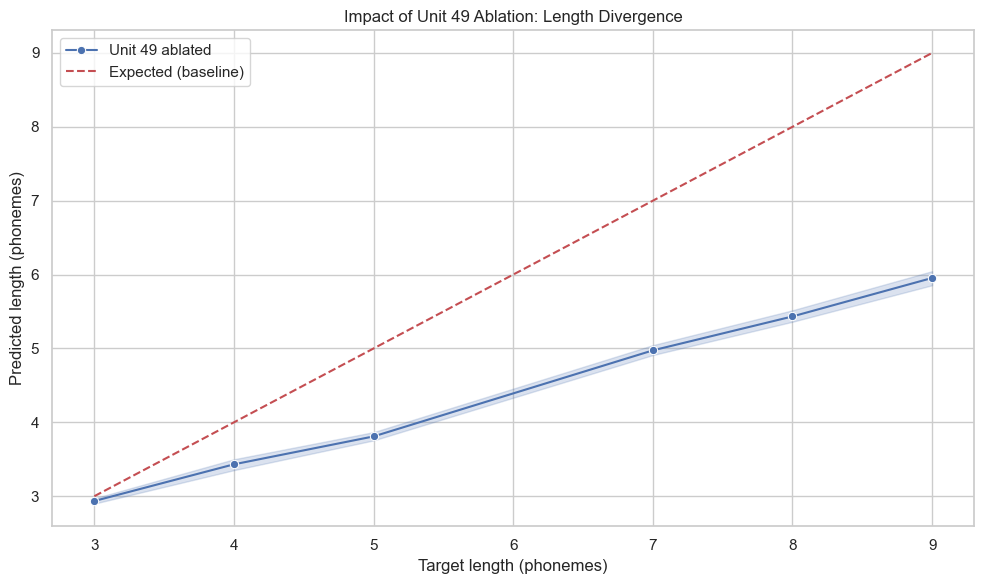

In [4]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x='L_gold', y='L_pred', label='Unit 49 ablated', marker='o')

# Perfect performance baseline
plt.plot([df['L_gold'].min(), df['L_gold'].max()], 
         [df['L_gold'].min(), df['L_gold'].max()], 
         'r--', label='Expected (baseline)')

plt.title("Impact of Unit 49 Ablation: Length Divergence")
plt.xlabel("Target length (phonemes)")
plt.ylabel("Predicted length (phonemes)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Visualization: Length Divergence

The plot below shows how predicted length diverges from target length. A healthy model should follow the diagonal (red dashed line).

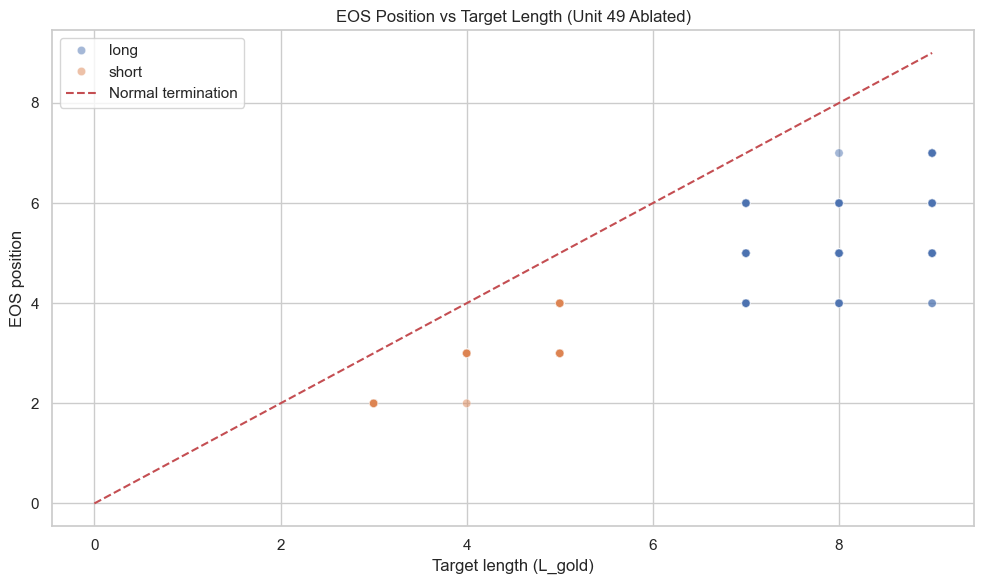

Early-EOS rate (among sequences with EOS): 100.00%


In [5]:
# Find EOS position in raw predictions
df['pred_raw'] = df['Prediction'].apply(lambda x: parse_tokens(x, keep_special=True))
df['eos_pos'] = df['pred_raw'].apply(lambda t: t.index('<EOS>') if '<EOS>' in t else None)

# Plot only items with EOS
df_with_eos = df[df['eos_pos'].notna()].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_with_eos, x='L_gold', y='eos_pos', alpha=0.5, hue='Size')

max_val = int(df['L_gold'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Normal termination')

plt.title("EOS Position vs Target Length (Unit 49 Ablated)")
plt.xlabel("Target length (L_gold)")
plt.ylabel("EOS position")
plt.legend()
plt.tight_layout()
plt.show()

early_eos_rate_eos = (df_with_eos['eos_pos'] < df_with_eos['L_gold']).mean()
print(f"Early-EOS rate (among sequences with EOS): {early_eos_rate_eos:.2%}")

## 5. EOS Position Analysis

Where exactly does the model place the `<EOS>` token? Points below the diagonal indicate premature termination.

In [6]:
df_with_eos["early_eos"] = df_with_eos["eos_pos"] < df_with_eos["L_gold"]

# Early-EOS rate by size category
rates = df_with_eos.groupby("Size")["early_eos"].mean().sort_index()
gaps = (df_with_eos["L_gold"] - df_with_eos["eos_pos"]).groupby(df_with_eos["Size"]).mean()

print("Early-EOS rate by word size:")
print((100 * rates).round(2).astype(str) + "%")
print("\nMean truncation severity (L_gold - eos_pos):")
print(gaps.round(2))

Early-EOS rate by word size:
Size
long     100.0%
short    100.0%
Name: early_eos, dtype: object

Mean truncation severity (L_gold - eos_pos):
Size
long     2.45
short    1.16
dtype: float64


## 6. Breakdown by Word Length

Does the ablation affect short and long words differently?

In [7]:
# Global statistics
eos_coverage = df['eos_pos'].notna().mean()
df["early_eos_global"] = df["eos_pos"].notna() & (df["eos_pos"] < df["L_gold"])
early_global_rate = df["early_eos_global"].mean()

print("=" * 50)
print("ABLATION SUMMARY: UNIT 49")
print("=" * 50)
print(f"EOS coverage: {eos_coverage:.2%} of items")
print(f"Global truncation rate: {early_global_rate:.2%} of items")
print("-" * 50)

ABLATION SUMMARY: UNIT 49
EOS coverage: 79.25% of items
Global truncation rate: 79.25% of items
--------------------------------------------------


## 7. Summary Statistics

In [8]:
print("CONCLUSION:")
print(f"These results support the hypothesis that unit 49 contributes to a")
print(f"sequence-maintenance / termination-control mechanism.")
print(f"After ablation, {early_global_rate:.2%} of items show premature <EOS>.")

CONCLUSION:
These results support the hypothesis that unit 49 contributes to a
sequence-maintenance / termination-control mechanism.
After ablation, 79.25% of items show premature <EOS>.


## 8. Conclusion

In [9]:
severity = (df.loc[df["eos_pos"].notna(), "L_gold"] - df.loc[df["eos_pos"].notna(), "eos_pos"]).mean()
print(f"Mean truncation severity: {severity:.2f} phonemes")

Mean truncation severity: 1.97 phonemes
